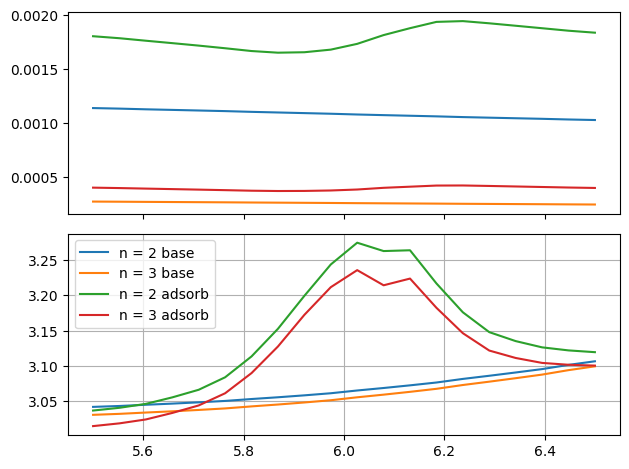

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

import snompy


# Plot output
fig, axes = plt.subplots(nrows=2, sharex=True)
plt.grid()
all_signal = []
all_phase = []
for option in ["base", "adsorb"]:
    for L in [1005]:
        for n in [2,3]:
            # Set some experimental parameters
            A_tip = 50e-9  # AFM tip tapping amplitude
            r_tip = 75e-9  # AFM tip radius of curvature
            L_tip = L*pow(10,-9)  # Semi-major axis length of ellipsoid tip model
            g_factor=0.7-0.06j
            d_Q0=0.8
            theta_in = np.deg2rad(60)  # Light angle of incidence
            c_r = 0.5  # Experimental weighting factor
            nu_vac = 10000 / np.linspace(5.5, 6.5, 20) * 1e2  # Vacuum wavenumber
            method = "multi"  # The FDM method to use

            # Semi-infinite superstrate and substrate
            eps_air = 1

            SN_eps1 = [5.214240758,5.189577913,5.158596071,5.132234122,5.105476174,5.078323095,5.044912859,5.016982676,4.988657899,4.960383558,4.926336716,4.897716309,4.870017466,4.841908539,4.808918896,4.782182184,4.755462076,4.729192562,4.698031228,4.672649601]
            SN_eps2 = [0.052369789,0.0579366392,0.0654543234,0.072514124,0.0803332992,0.088994664,0.1006117904,0.11131008,0.1229785872,0.13564866,0.1522028068,0.1670054568,0.182778232,0.1994103436,0.220372171,0.238590625,0.257386459,0.2766623496,0.3003250768,0.3204249834]
            water_eps1 = [1.68466944,1.67297584,1.6582095039,1.6426922604,1.6264349851,1.6070444736,1.5840760944,1.5651490064,1.5609382144,1.5785945364,1.6284318,1.6954608,1.76080923,1.82452608,1.845517,1.83946575,1.8278883344,1.8149778679,1.8018807975,1.79138436]
            water_eps2 = [0.0301136,0.0333723,0.038144636,0.045785896,0.05502507,0.07080512,0.097814656,0.133835136,0.178099248,0.235752488,0.29262608,0.33018968,0.31466564,0.26163144,0.20572272,0.16318352,0.14114496,0.12431256,0.1129463,0.1049776]
            # ads_eps1 = [1.6264349851,1.6070444736,1.5840760944,1.5651490064,1.5609382144,1.5785945364,1.6284318,1.6954608,1.76080923,1.82452608,1.845517,1.83946575,1.8278883344,1.8149778679,1.8018807975,1.79138436,1.79138436,1.79138436,1.79138436,1.79138436]
            # ads_eps2 = [0.01,0.02,0.03,0.04,0.06,0.1,0.2,0.3,0.35,0.3,0.2,0.1,0.08,0.06,0.05,0.05,0.05,0.05,0.05,0.05]
            ads_eps1 = [1.6426922604,1.6264349851,1.6070444736,1.5840760944,1.5651490064,1.5609382144,1.5785945364,1.6284318,1.6954608,1.76080923,1.82452608,1.845517,1.83946575,1.8278883344,1.8149778679,1.8018807975,1.79138436,1.79138436,1.79138436,1.79138436]
            ads_eps2 = [0.02,0.02,0.02,0.03,0.04,0.06,0.1,0.18,0.3,0.25,0.1,0.03,0,0,0,0,0,0,0,0]
            # ads_eps2 = [0.,0.,0.,0.,0.,0.,0.,0.,0.33018968,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.,0.]

            
            eps_SN = []
            eps_H2O = []
            eps_ads = []
            for i in range(len(nu_vac)):
                eps_SN.append(SN_eps1[i] + SN_eps2[i]*1j)
                eps_H2O.append(water_eps1[i] + water_eps2[i]*1j)
                eps_ads.append(ads_eps1[i] + ads_eps2[i]*10j)
                # eps_ads.append(1)
            # eps_SN = 4.9 + 1j*0.14
            # eps_H2O = 1.58 + 1j*0.27
            t = np.array([50]) * 1e-9
            if option == "base":
                sample_SN = snompy.Sample(
                    eps_stack=(eps_air, eps_SN, eps_air),
                    t_stack=[[15*1e-9]],
                    nu_vac=nu_vac,
                )
            elif option == "adsorb":
                sample_SN = snompy.Sample(
                    eps_stack=(eps_air, eps_SN, eps_ads, eps_H2O),
                    t_stack=[[15*1e-9], [1*1e-9]],
                    nu_vac=nu_vac,
                )
                
            eps_Si = 11.6
            sample_ref = snompy.Sample(
                eps_stack=(eps_air, eps_SN, eps_Si),
                t_stack=(t[:,np.newaxis],),
                nu_vac=nu_vac,
            )

            # Model of Au dielectric function from ref [2] below
            eps_Au = snompy.sample.drude_perm(nu_vac, nu_plasma=7.25e6, gamma=2.16e4)
            sample_Au = snompy.bulk_sample(eps_sub=eps_Au, eps_env=eps_air, nu_vac=nu_vac)
            eps_Si = 11.6
            sample_Si = snompy.bulk_sample(eps_sub=eps_Si, eps_env=eps_air, nu_vac=nu_vac)

            # Measurement
            alpha_eff_SN = snompy.fdm.eff_pol_n(
                sample=sample_SN, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method,  z_tip=2e-9, g_factor=g_factor 
            )
            r_coef_SN = sample_SN.refl_coef(theta_in=theta_in)
            sigma_SN = (1 + c_r * r_coef_SN) ** 2 * alpha_eff_SN

            # Silicon reference
            alpha_eff_Si = snompy.fdm.eff_pol_n(
                sample=sample_ref, A_tip=A_tip, n=n, r_tip=r_tip, L_tip=L_tip, method=method, 
            )
            r_coef_Si = sample_ref.refl_coef(theta_in=theta_in)
            sigma_Si = (1 + c_r * r_coef_Si) ** 2 * alpha_eff_Si

            # Normalised complex scattering
            eta_n = [sigma_SN] 


            # For neater plotting
            nu_per_cm = nu_vac * 1e-2
            t_nm =  t * 1e9

            # axes[0].plot(nu_per_cm, np.abs(eta_n),label="n = "+str(n))
            # axes[1].plot(nu_per_cm, np.angle(eta_n),label="n = "+str(n))
            for t, sigma in zip(t_nm, eta_n):
                all_signal.append(np.abs(sigma))
                all_phase.append(np.angle(sigma))
                axes[0].plot(np.divide(10000,nu_per_cm), np.abs(sigma),label="n = "+str(n))
                #axes[1].plot(np.divide(10000,nu_per_cm), (np.angle(sigma)+2*np.pi)%np.pi,label="n = "+str(n))
                #angles = [angle+np.pi if angle < 0 else angle-np.pi for angle in np.angle(sigma)]
                mod_angles = [(angle+2*np.pi)%np.pi for angle in np.angle(sigma)]
                angles = []
                for index, angle in enumerate(mod_angles):
                    if index == 0:
                        angles.append(angle)
                    elif angle-angles[index-1] > np.pi*0.95:
                        angles.append(angle-np.pi)
                    elif angles[index-1]-angle > np.pi*0.95:
                        angles.append(angle+np.pi)
                    else:
                        angles.append(angle)
                # if n==3 and option=="adsorb":
                #     angles = np.subtract(angles,np.pi)
                axes[1].plot(np.divide(10000,nu_per_cm), angles,label="n = "+str(n) + " " + option)

            # axes[0].set_ylabel(r"signal / a.u.")
            # axes.set_axisbelow("True")
            # axes.set(
            #     xlabel=r"Wavenumber (cm$^{-1}$)",
            #     ylabel=r"Complex Signal Component (radians)",
            #     xlim=(nu_per_cm.max(), nu_per_cm.min()),
            # )
            plt.legend()
# axes[0].plot(nu_per_cm, all_signal[1]/all_signal[2],label="3/1")
# axes[1].plot(nu_per_cm, all_phase[1]/all_phase[2],label="3/1")
#plt.gca().invert_xaxis()
fig.tight_layout()
plt.show(block=False)